In [10]:
import math
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [11]:
raw_img = cv2.imread('sar_1.jpg')
gray_canvas = cv2.cvtColor(raw_img, cv2.COLOR_BGR2GRAY)

In [12]:
# ==============================================================================
# ЗАДАНИЕ 1 & 2. Разрастание регионов и исследование критериев однородности
# ==============================================================================


def criterion_mean_diff(src_img, region_mask, curr_pt, thresh):
    avg_val = np.mean(src_img[region_mask > 0])
    return abs(avg_val - src_img[curr_pt]) <= thresh

def criterion_local_delta(src_img, region_mask, curr_pt, thresh):
    y, x = curr_pt
    patch = src_img[max(0, y - 1) : y + 2, max(0, x - 1) : x + 2]
    return abs(src_img[curr_pt] - np.mean(patch)) <= thresh


def criterion_std_dev(src_img, region_mask, curr_pt, thresh):
    current_pixels = src_img[region_mask > 0]
    std_val = np.std(current_pixels) if len(current_pixels) > 0 else 0
    ref_mean = np.mean(current_pixels) if len(current_pixels) > 0 else src_img[curr_pt]
    return abs(src_img[curr_pt] - ref_mean) <= (thresh + 0.5 * std_val)

In [13]:
def grow_region_segment(img, seed, homo_func, radius=3, tol=25):
    h, w = img.shape
    segmented_mask = np.zeros((h, w), dtype=np.uint8)
    segmented_mask[seed] = 1

    iterations = 0
    while True:
        iterations += 1
        new_pixels = np.zeros((h, w), dtype=np.uint8)

        for r in range(radius, h - radius):
            for c in range(radius, w - radius):
                if segmented_mask[r, c] == 0:
                    neighborhood = segmented_mask[
                        r - radius : r + radius + 1, c - radius : c + radius + 1
                    ]
                    if np.any(neighborhood):
                        if homo_func(img, segmented_mask, (r, c), tol):
                            new_pixels[r, c] = 1

        added_count = np.count_nonzero(new_pixels)
        segmented_mask |= new_pixels

        if added_count == 0 or iterations > 100:
            break

    return segmented_mask * 255

In [14]:
seed_coords = (250, 250)

mask_mean = grow_region_segment(
    gray_canvas, seed_coords, criterion_mean_diff, radius=3, tol=28
)
mask_local = grow_region_segment(
    gray_canvas, seed_coords, criterion_local_delta, radius=3, tol=18
)
mask_std = grow_region_segment(
    gray_canvas, seed_coords, criterion_std_dev, radius=3, tol=22
)

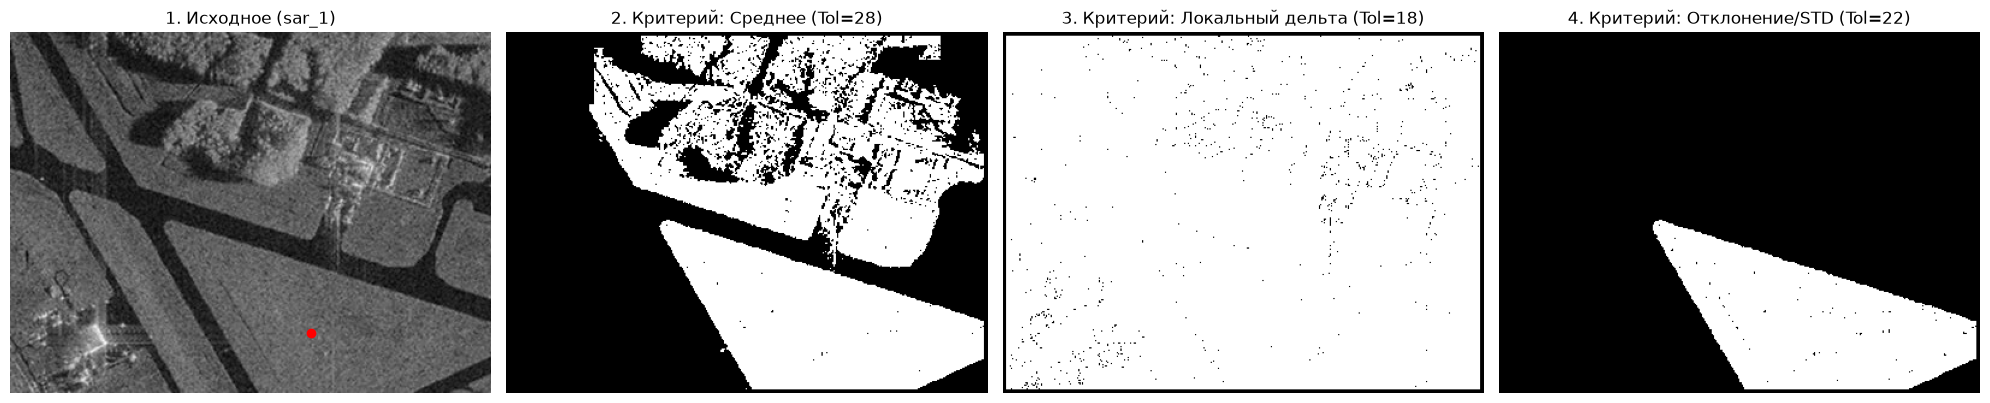

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(gray_canvas, cmap='gray')
axes[0].set_title('1. Исходное (sar_1)')
axes[0].plot(seed_coords[1], seed_coords[0], 'ro') 

axes[1].imshow(mask_mean, cmap='gray')
axes[1].set_title('2. Критерий: Среднее (Tol=28)')

axes[2].imshow(mask_local, cmap='gray')
axes[2].set_title('3. Критерий: Локальный дельта (Tol=18)')

axes[3].imshow(mask_std, cmap='gray')
axes[3].set_title('4. Критерий: Отклонение/STD (Tol=22)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

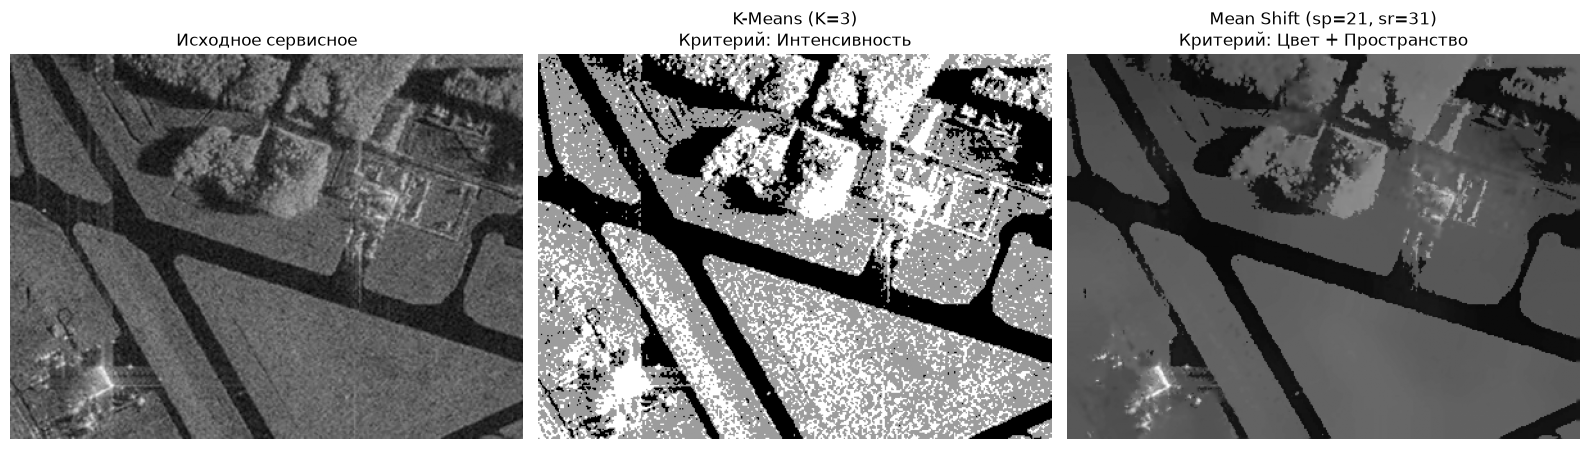

In [16]:
pixels_vec = np.float32(gray_canvas.reshape((-1, 1)))
term_crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
num_clusters = 3

_, labels, cluster_centers = cv2.kmeans(
    pixels_vec, num_clusters, None, term_crit, 10, cv2.KMEANS_RANDOM_CENTERS
)
kmeans_img = np.uint8(cluster_centers)[labels.flatten()].reshape(
    gray_canvas.shape
)

spatial_rad, color_rad = 21, 31
meanshift_res = cv2.pyrMeanShiftFiltering(
    raw_img, sp=spatial_rad, sr=color_rad
)
meanshift_gray = cv2.cvtColor(meanshift_res, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.title('Исходное сервисное')
plt.imshow(gray_canvas, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f'K-Means (K={num_clusters})\nКритерий: Интенсивность')
plt.imshow(kmeans_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(
    f'Mean Shift (sp={spatial_rad}, sr={color_rad})\nКритерий: Цвет + Пространство'
)
plt.imshow(meanshift_gray, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

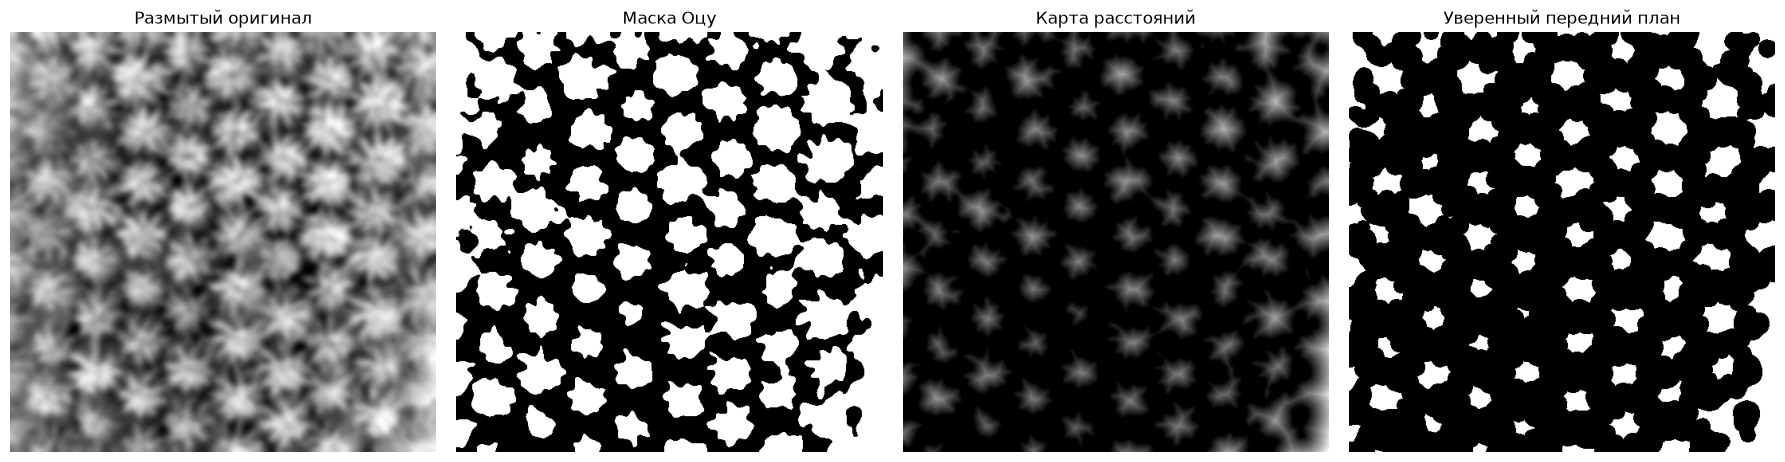

In [17]:
# ==============================================================================
# ЗАДАНИЕ 3. Watershed + Distance Transform для подсчета пальмовых деревьев
# ==============================================================================

palm_bgr = cv2.imread('palm_1.jpg')
palm_gray = cv2.cvtColor(palm_bgr, cv2.COLOR_BGR2GRAY)

smooth_palm = cv2.GaussianBlur(palm_gray, (25, 25), sigmaX=0)

_, bin_palm = cv2.threshold(
    smooth_palm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

dist_map = cv2.distanceTransform(bin_palm, cv2.DIST_L2, maskSize=5)

_, sure_foreground = cv2.threshold(
    dist_map, 0.20 * dist_map.max(), 255, cv2.THRESH_BINARY
)
sure_foreground = np.uint8(sure_foreground)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
stage_titles = [
    'Размытый оригинал',
    'Маска Оцу',
    'Карта расстояний',
    'Уверенный передний план',
]
stage_images = [smooth_palm, bin_palm, dist_map, sure_foreground]

for ax, img, title in zip(axes, stage_images, stage_titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

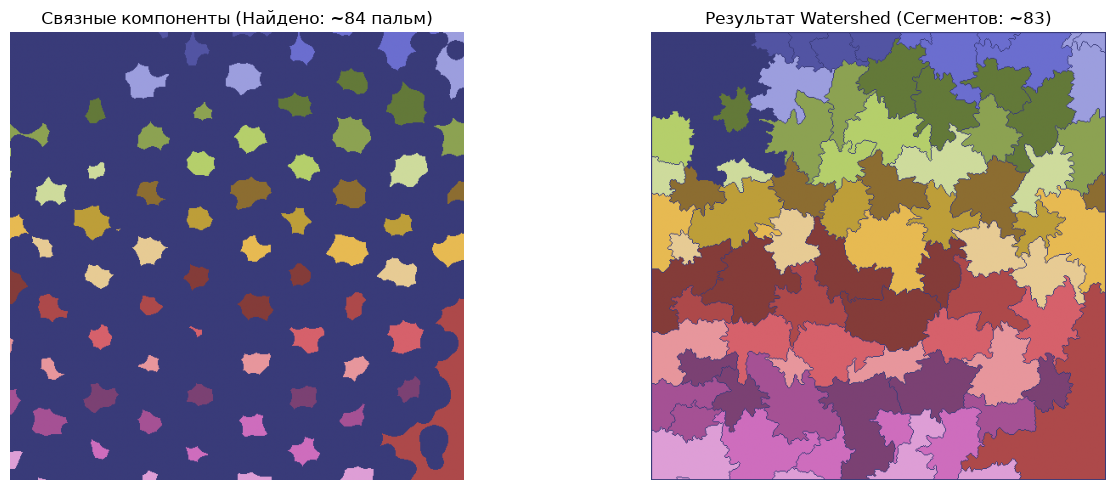

===> Итоговое количество выявленных пальм: 83


In [18]:
num_labels, markers = cv2.connectedComponents(sure_foreground)

total_palms_initial = num_labels - 1

watershed_markers = cv2.watershed(palm_bgr, markers.copy())

unique_labels = np.unique(watershed_markers)
valid_palms = len(unique_labels[unique_labels > 0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.imshow(markers, cmap='tab20b')
ax1.set_title(f'Связные компоненты (Найдено: ~{total_palms_initial} пальм)')
ax1.axis('off')

ax2.imshow(watershed_markers, cmap='tab20b')
ax2.set_title(f'Результат Watershed (Сегментов: ~{valid_palms})')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f'===> Итоговое количество выявленных пальм: {valid_palms}')